In [1]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/pmos4.mat')
nmos4 = lk('lookup_table/nmos4.mat')

5T OTA
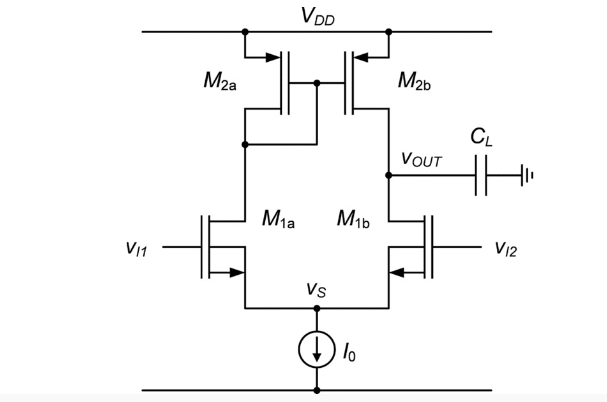
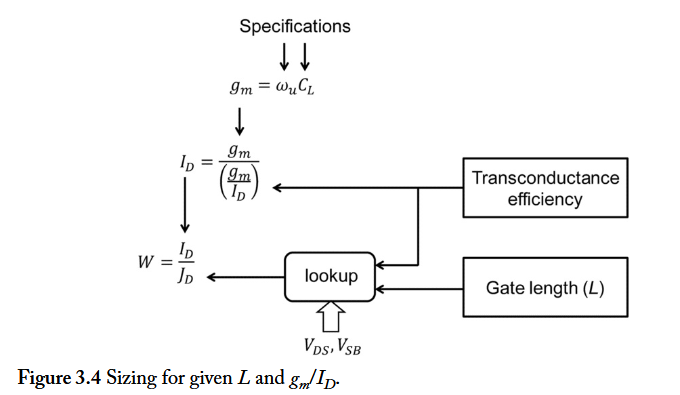

In [2]:
#Specification
FU = 100e6
CL = 1e-12
VDD = 2.7
V_IC = 1.35

In [3]:
#Hypothèse : L et GM
L12 = 1
gmID1 = 15
gmID2 = 10

In [4]:
print(nmos4['VSB'])

[0.  0.1]


In [5]:
CselfLoading = 0

#gm and ID, from Spec and Hypothesis
gm1 = 2*3.14159*FU*CL
ID = gm1 / gmID1
#VGS from lookupVGS, L and GM_ID
# Find VDS1 and 
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, L=L12, VDS=0.6, VSB=0) #Fist estimation with vds default
VGS2 = pmos4.lookupVGS(GM_ID=gmID2, L=L12, VDS=0.6, VSB=0) #Fist estimation with vds default
VGS2 = pmos4.lookupVGS(GM_ID=gmID2, L=L12, VDS=VGS2, VSB=0) #Second with VDS = VGS (current mirror)
VS = V_IC - VGS1
VD = VDD - VGS2
VDS1 = VD - VS
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, L=L12, VDS=VDS1, VSB=0) #Second with VDS
##Design terminé##

#Calcul Gain
gdsID1 = nmos4.look_up('GDS_ID', GM_ID=gmID1, VDS=VDS1, L=L12, VSB=0)
gdsID2 = pmos4.look_up('GDS_ID', GM_ID=gmID2, VDS=VDS1, L=L12, VSB=0)
AV0 = gmID1 / (gdsID1 + gdsID2)

print('AV0 = %.2F' % AV0)
print('gm1 = %.2F uS' % (gm1 * 1e6))


for m in range(1,10,1):
    #self loading
    gm1 = 2*3.14159*FU*(CL+CselfLoading)
    ID = gm1 / gmID1
    #Denormalization
    JD1 = nmos4.lookup('ID_W', GM_ID=gmID1, VDS=VDS1, L=L12, VSB=0)
    JD2 = pmos4.lookup('ID_W', GM_ID=gmID2, VDS=VGS2, L=L12, VSB=0)
    W1 = ID/JD1
    W2 = ID/JD2
    print('ID = %.2F uA' % (ID* 1e6))
    print('W1 = %.2F um' % (W1))
    print('W2 = %.2F um' % (W2))
    CDD1 = W1 * nmos4.look_up('CDD_W', GM_ID=gmID1, L=L12, VSB=0)
    CDD2 = W2 * pmos4.look_up('CDD_W', GM_ID=gmID2, L=L12, VSB=0)
    CselfLoading = CDD1 + CDD2


AV0 = 176.74
gm1 = 628.32 uS
ID = 41.89 uA
W1 = 50.67 um
W2 = 52.32 um
ID = 51.05 uA
W1 = 61.75 um
W2 = 63.77 um
ID = 53.06 uA
W1 = 64.18 um
W2 = 66.28 um
ID = 53.50 uA
W1 = 64.71 um
W2 = 66.82 um
ID = 53.59 uA
W1 = 64.83 um
W2 = 66.94 um
ID = 53.61 uA
W1 = 64.85 um
W2 = 66.97 um
ID = 53.62 uA
W1 = 64.86 um
W2 = 66.98 um
ID = 53.62 uA
W1 = 64.86 um
W2 = 66.98 um
ID = 53.62 uA
W1 = 64.86 um
W2 = 66.98 um


In [6]:
print('AV0 = %.2F' % (20*np.log10(AV0)))
print('gm1 = %.2F uS' % (gm1 * 1e6))    
print('ID = %.2F uA' % (ID* 1e6))
print('W1 = %.2F um' % (W1))
print('W2 = %.2F um' % (W2))

AV0 = 44.95
gm1 = 804.28 uS
ID = 53.62 uA
W1 = 64.86 um
W2 = 66.98 um
